# Hypothesis Testing And Interval Estimation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.font_manager as fm
from matplotlib import ticker
import pyreadr 
import statsmodels.formula.api as smf

### Figure 4.1

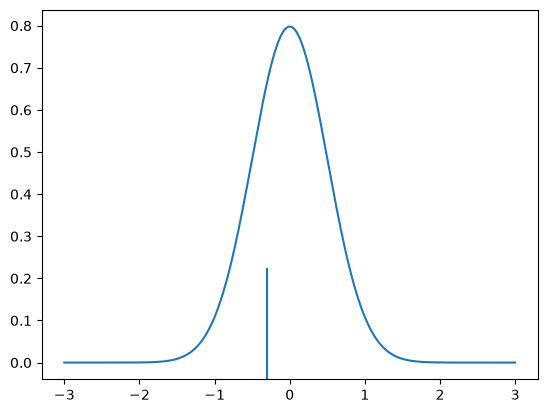

In [ ]:
from scipy.stats import norm

x= np.linspace(-3,3, 1000)
y= norm.pdf(x, loc=0, scale=0.5)

plt.plot(x,y)

#ax vertical line, at x=-0.3, starting from y= 0 and ending at y= 0.3
plt.axvline(-0.3, 0, 0.3)
plt.show()

# The text can simply be added via ax.text and object based visualization 

### Figure 4.4

Text(3, 0.25, '2.5% of normal \n distribution is to \n right of 1.96')

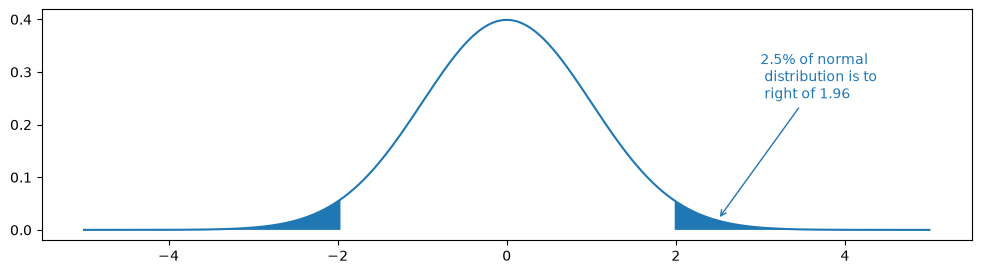

In [ ]:
fig, ax= plt.subplots(figsize= (12,3))

x= np.linspace(-5,5, 1000)
y= norm.pdf(x, loc=0, scale=1)

ax.plot(x,y)
ax.fill_between(x,y, where=(x >=1.98) | (x<=-1.96))
ax.annotate("2.5% of normal \n distribution is to \n right of 1.96", 
            arrowprops={"arrowstyle": "->", "color":"C0"}, color="C0",
            xy=(2.5,0.02), xytext=(3,0.25))



### Figure 4.7

This could be made by simpler ways but we will try to make them from the simulations described in the book, it might be better for someone following along to finish computing corner and understanding the material really well, if this code comes across as confusing

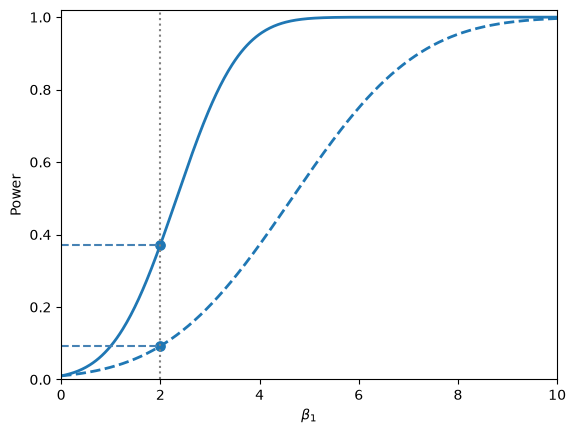

In [ ]:
# 1- We set our significance level as we do in hypothesis testing

alpha = 0.01

# 2- Given the test(one tailed here), alpha and null hypothesis we will find out the critical values
        # Our t-stat follows a t distribution we have assumed that the dof for t-Test is large i.e. large sample, enough to get normal distribution, these critical values otherwise would have been found out using scipy.stats import t and tcrit= t.ppf(1-alpha, df=) 



# ppf(α) tells us the zscore that leave α area to the left and 1-alpha is 0.99, so zcrit is storing the value of the x which has 99% of distribution to the left
# cdf is given x what is the area, ppf is given area what is the x
zcrit = norm.ppf(1-alpha)   # So zcrit basically stores 2.326.... and at this x 99% we cover 99% of area under the normal curve
 
# This is our critical value, we reject or fail to reject null using this value


# We make many betas, beta can range form 0 to 10, this is for the figure, as you can see in it, we see how our power changes as our true beta becomes more and more extreme than our null Beta which is zero
# These are true betas, not estimated betas
beta = np.linspace(0,10,500)

#standard error we will use this later
se1 = 1
se2 = 2

# This is the part that differs from book to code, what happens ideally, we have 500 true values that we will plot on x one by one to see that if true value is say 5 what will be the area under acceptance region i.e. we fail to reject null even though true value as 5 (type 2 error)
    # So ideally to show this effect we set beta= 5 and form a normal distribution centered at 5(or t if sample is small) , now our zcrit is still based on the assumption that true beta is 0, zcrit of 2.326 will actually be quite far left of a distribution centered at 5, so the area under the acceptance (left of 2.326) will be tiny (small chance of type 2 error, power is high)
        # But the issue is that then we have to plot a different normal constantly and keep finding the cdf of new curves (here 500) which is a waste of computing power. We can fix this issue by the same way as we solve normal distribution questions by hand. We standardize our normal and then use the table to find the answer based on standard


# Say beta= 5, SE= 2, the curve is centered at 5 and is wider than if SE=1, power is still the shaded region to the right (region of rejection)
    # Now as the theory says we reject the null if t > zcrit ------> beta(hat)/SE(beta(hat)) > 2.326
    # Simplifying we reject the null if beta(hat) > zcrit x SE(beta(hat))
    # So we have, reject if beta(hat) > 2.326 x 2
        # Beta (hat) has distribution of normal with mean at 5, to make it zero we simply subtract on both sides
        # reject if beta (hat)- beta > zcrit x SE - beta -------> beta(hat)- 5 > 2.326 x 2 - 5       (Now distribution is centered 0)
        # Now we just divide by SE on both sides
        # reject if (beta(hat) - beta) / SE  > zcrit - beta/SE --------> beta(hat)-beta > 2.326 - 5/2  (Now SE is 1)    
            # Now we know that power is the area of rejection, i.e. area to the right, norm.cdf will give area to the left, to make it area to the right we subtract by 1

power1 = 1 - norm.cdf(zcrit - beta/se1)
power2 = 1 - norm.cdf(zcrit - beta/se2)


# The example of true beta being 2, i am putting this into our formula so that we can change it in the future as well
beta_true_example = 2

p1 = 1 - norm.cdf(zcrit - beta_true_example/se1)
p2 = 1 - norm.cdf(zcrit - beta_true_example/se2)

plt.figure()

# The plot
plt.plot(beta, power1, lw=2, label="SE = 1")
plt.plot(beta, power2, '--', lw=2, label="SE = 2", color="C0")

# Vertical dotted line
plt.axvline(beta_true_example, color='gray', ls=':')

# To just make the 2 points for our example on our 2 curves we will use scatter plot
plt.scatter(beta_true_example, p1, s=45)
plt.scatter(beta_true_example, p2, s=45, color="C0")


# The 2 horizontal lines
plt.hlines(p1, 0, beta_true_example,
           ls='--', color='steelblue')

plt.hlines(p2, 0, beta_true_example,
           ls='--', color='steelblue')

plt.xlabel(r'$\beta_1$')
plt.ylabel("Power")

plt.xlim(0,10)
plt.ylim(0,1.02)

plt.show()

# Computing Corner

**1.** 

The inverse probability distribution in scipy.stats is ppf which stands for percent point function, and this calculates inverse of Cumulative Distribution Functions (CDF) 

The primary use of inverse probability distribution is to find critical values

Critical values for a two tailed test with n-k=100 α= 0.05 can be found as follows

In [ ]:
import scipy.stats as stats

# For two tailed test we half our alpha
alpha= 0.05
tcrit= stats.t.ppf(1-(alpha/2), df=100)
print(tcrit, "For two tailed test")


# For one tailed test 
alpha= 0.05
tcrit= stats.t.ppf(1-(alpha), df=100)
print(tcrit, "For one tailed test")

1.983971518523552 For two tailed test
1.6602343260853392 For one tailed test


**2.**

For normal we use stats.norm, to see other distributions we can do dir(stats)

**3.**

Taking out p-value is easy once you understand what it is, it is simply the probability of getting the t ATLEAST as extreme as we got. So simply the area to the right of our t statistic

For a t statistic of 4.32 based on a 2 tailed test with dof=1908 we will get p-value of:

In [ ]:
# Simply area to the right of our t, but this is only one sided area
p_val= 1-stats.t.cdf(4.32, df= 1908)

# Passing a f string so that answer in not in scientific notation
print(f"For 2 tailed test: {2*p_val:.7f}")
print(f"For 1 tailed test: {p_val:.7f}")

For 2 tailed test: 0.0000164
For 1 tailed test: 0.0000082


**4.**

You can find out confidence interval using scipy.stats and statsmodels libraries, the choice usually depends on the task at hand. If we have to do statistics exercises then scipy.stats is better suited however for regressions statsmodels is an obvious choice 

In [ ]:
# Scipy
x = np.array([4,5,6,7,8,9,10])

# Confidence interval on a t distribution 
ci = stats.t.interval(
    confidence=0.95,
    df=len(x)-1,
    loc=np.mean(x),
    scale=stats.sem(x)     #stats.sem estimates the standard error or mean --> s/√n-1
)

print(ci)

In [87]:
# Statsmodels

DonutDF= pd.read_csv(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\donuts.csv")
display(DonutDF.info())

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    13 non-null     str    
 1   donuts  13 non-null     float64
 2   weight  13 non-null     float64
 3   child   13 non-null     float64
 4   male    13 non-null     float64
dtypes: float64(4), str(1)
memory usage: 652.0 bytes


None

In [92]:
DonutOLS= smf.ols(
    formula="weight ~ donuts",
    data= DonutDF
).fit()


# coefficients
display("Coefficients", DonutOLS.params)

# standard errors
display("Standard errors", DonutOLS.bse)

# t statistics
display("t stat", DonutOLS.tvalues)

# p-values
display("p value", DonutOLS.pvalues)

# confidence intervals
display("Confidence intervals", DonutOLS.conf_int())

'Coefficients'

Intercept    121.613413
donuts         9.223526
dtype: float64

'Standard errors'

Intercept    16.593160
donuts        1.959436
dtype: float64

't stat'

Intercept    7.329129
donuts       4.707235
dtype: float64

'p value'

Intercept    0.000015
donuts       0.000643
dtype: float64

'Confidence intervals'

,0,1
Intercept,85.092114,158.134712
donuts,4.910836,13.536216


**5.**

Done in figure 4.7

# Exercises

# 1